In [1]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


In [2]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

In [3]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

In [4]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


In [5]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


In [6]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


In [7]:
class SpectralTransformer(nn.Module):
    def __init__(self, input_size=1530, patch_size=51, 
                 d_model=128, nhead=8, num_layers=3, dropout=0.3):
        super(SpectralTransformer, self).__init__()
        
        # Number of patches
        self.num_patches = input_size // patch_size  # 1530 // 51 = 30
        self.patch_size  = patch_size
        self.d_model     = d_model
        
        # ── Patch embedding ──
        # Converts each patch of 51 points into d_model dimensions
        self.patch_embedding = nn.Linear(patch_size, d_model)
        
        # ── Positional encoding ──
        # Tells the model where each patch is in the spectrum
        self.pos_embedding = nn.Parameter(
            torch.randn(1, self.num_patches, d_model)
        )
        
        # ── Transformer encoder ──
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,          # 8 attention heads
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers  # 3 transformer blocks
        )
        
        # ── Output layers ──
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch, 1530)
        batch_size = x.shape[0]
        
        # Split into patches
        # (batch, 1530) → (batch, 30, 51)
        x = x.view(batch_size, self.num_patches, self.patch_size)
        
        # Embed each patch
        # (batch, 30, 51) → (batch, 30, d_model)
        x = self.patch_embedding(x)
        
        # Add positional encoding
        x = x + self.pos_embedding
        x = self.dropout(x)
        
        # Transformer encoder
        # (batch, 30, d_model) → (batch, 30, d_model)
        x = self.transformer(x)
        
        # Global average pooling across patches
        # (batch, 30, d_model) → (batch, d_model)
        x = x.mean(dim=1)
        
        # Final prediction
        # (batch, d_model) → (batch, 1)
        x = self.fc_layers(x)
        return x.squeeze(1)  # → (batch,)

# Test architecture
model_test = SpectralTransformer(
    input_size=1530, patch_size=51,
    d_model=128, nhead=8,
    num_layers=3, dropout=0.3
)
print(model_test)
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters()):,}")

# Test with dummy input
dummy = torch.randn(4, 1530)
out   = model_test(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4,)")

SpectralTransformer(
  (patch_embedding): Linear(in_features=51, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=T

In [8]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=100, batch_size=32, lr=1e-4):

    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    X_v  = torch.FloatTensor(X_val).to(device)
    y_v  = torch.FloatTensor(y_val).to(device)

    dataset   = TensorDataset(X_tr, y_tr)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.SmoothL1Loss(beta=0.02)
    optimizer = optim.AdamW(model.parameters(),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(loader),
                    epochs=epochs)

    model.to(device)

    best_val_loss = np.inf
    best_weights  = None
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_v)
            val_loss   = criterion(y_val_pred, y_v).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} — "
                  f"Train Loss: {avg_train_loss:.5f}  "
                  f"Val Loss: {val_loss:.5f}")

    model.load_state_dict(best_weights)
    print(f"\nBest validation loss: {best_val_loss:.5f}")
    return model, train_losses, val_losses

In [9]:
results_transformer = []

for combo_name, preprocess_fn in preprocessing_combos.items():
    print(f"\n{'='*50}")
    print(f"Testing: {combo_name}")
    print(f"{'='*50}")

    try:
        X_combo = preprocess_fn(X)
    except Exception as e:
        print(f"  Failed: {e}")
        continue

    # ── 80/20 split with a SEPARATE validation slice ──
    # test set is held out and never used for checkpoint selection
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )
    # carve validation out of the training portion, not the test set
    X_tr2, X_val, y_tr2, y_val = train_test_split(
        X_tr, y_tr, test_size=0.2, random_state=42
    )

    torch.manual_seed(42)
    model_combo = SpectralTransformer(
        input_size=1530, patch_size=51,
        d_model=128, nhead=8,
        num_layers=3, dropout=0.3
    )
    model_combo, _, _ = train_model(
        model=model_combo,
        X_train=X_tr2, y_train=y_tr2,
        X_val=X_val,   y_val=y_val,     # validation, NOT the test set
        epochs=100, batch_size=32, lr=1e-4
    )

    model_combo.eval()
    with torch.no_grad():
        y_pred_te = model_combo(
            torch.FloatTensor(X_te).to(device)
        ).cpu().numpy()

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")

    all_true, all_pred = [], []

    for fold_idx, held_out in enumerate(cultivar_names):
        train_cults = [c for c in cultivar_names if c != held_out]
        val_cult    = train_cults[-1]        # one training cultivar for checkpointing
        fit_cults   = train_cults[:-1]

        X_tr_l, y_tr_l   = [], []
        X_val_l, y_val_l = [], []
        X_te_l, y_te_l   = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            if not spectra:
                continue
            # preprocess the whole cultivar as a BATCH so MSC has a
            # population to reference (per-spectrum MSC is meaningless)
            intens_batch = np.array([s[1] for s in spectra])   # (324, 1530)
            pre = preprocess_fn(intens_batch)

            if folder_name == held_out:
                X_te_l.extend(pre);  y_te_l.extend([meta['cys']] * len(pre))
            elif folder_name == val_cult:
                X_val_l.extend(pre); y_val_l.extend([meta['cys']] * len(pre))
            else:
                X_tr_l.extend(pre);  y_tr_l.extend([meta['cys']] * len(pre))

        torch.manual_seed(42)
        model_loco = SpectralTransformer(
            input_size=1530, patch_size=51,
            d_model=128, nhead=8,
            num_layers=3, dropout=0.3
        )
        model_loco, _, _ = train_model(
            model=model_loco,
            X_train=np.array(X_tr_l),  y_train=np.array(y_tr_l),
            X_val=np.array(X_val_l),   y_val=np.array(y_val_l),   # training cultivar
            epochs=100, batch_size=32, lr=1e-4
        )

        model_loco.eval()
        with torch.no_grad():
            y_pred_l = model_loco(
                torch.FloatTensor(np.array(X_te_l)).to(device)
            ).cpu().numpy()

        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)

        fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
        print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"\n  LOCO → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")

    results_transformer.append({
        "Preprocessing": combo_name,
        "RMSE_8020":     rmse_8020,
        "R2_8020":       r2_8020,
        "RPD_8020":      rpd_8020,
        "RMSE_LOCO":     rmse_loco,
        "R2_LOCO":       r2_loco,
        "RPD_LOCO":      rpd_loco,
    })

print("\n ALL TRANSFORMER COMBINATIONS DONE!")


print(f"\n{'='*50}")
print("Testing: Raw (no preprocessing)")
print(f"{'='*50}")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=0.2, random_state=42)

torch.manual_seed(42)
model_raw = SpectralTransformer(
    input_size=1530, patch_size=51,
    d_model=128, nhead=8,
    num_layers=3, dropout=0.3
)
model_raw, _, _ = train_model(
    model=model_raw,
    X_train=X_tr2, y_train=y_tr2,
    X_val=X_val,   y_val=y_val,
    epochs=100, batch_size=32, lr=1e-4
)

model_raw.eval()
with torch.no_grad():
    y_pred_raw = model_raw(
        torch.FloatTensor(X_te).to(device)
    ).cpu().numpy()

rmse_8020_raw = np.sqrt(mean_squared_error(y_te, y_pred_raw))
r2_8020_raw   = r2_score(y_te, y_pred_raw)
rpd_8020_raw  = y_te.std() / rmse_8020_raw
print(f"  80/20 → RMSE: {rmse_8020_raw:.4f}  R²: {r2_8020_raw:.4f}  RPD: {rpd_8020_raw:.4f}")

all_true_raw, all_pred_raw = [], []
for fold_idx, held_out in enumerate(cultivar_names):
    train_cults = [c for c in cultivar_names if c != held_out]
    val_cult    = train_cults[-1]

    X_tr_l, y_tr_l   = [], []
    X_val_l, y_val_l = [], []
    X_te_l, y_te_l   = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        if not spectra:
            continue
        intens_batch = np.array([s[1] for s in spectra])   # raw, no preprocessing
        if folder_name == held_out:
            X_te_l.extend(intens_batch);  y_te_l.extend([meta['cys']] * len(intens_batch))
        elif folder_name == val_cult:
            X_val_l.extend(intens_batch); y_val_l.extend([meta['cys']] * len(intens_batch))
        else:
            X_tr_l.extend(intens_batch);  y_tr_l.extend([meta['cys']] * len(intens_batch))

    torch.manual_seed(42)
    model_raw_loco = SpectralTransformer(
        input_size=1530, patch_size=51,
        d_model=128, nhead=8,
        num_layers=3, dropout=0.3
    )
    model_raw_loco, _, _ = train_model(
        model=model_raw_loco,
        X_train=np.array(X_tr_l),  y_train=np.array(y_tr_l),
        X_val=np.array(X_val_l),   y_val=np.array(y_val_l),
        epochs=100, batch_size=32, lr=1e-4
    )

    model_raw_loco.eval()
    with torch.no_grad():
        y_pred_l = model_raw_loco(
            torch.FloatTensor(np.array(X_te_l)).to(device)
        ).cpu().numpy()

    fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
    print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")
    all_true_raw.extend(y_te_l)
    all_pred_raw.extend(y_pred_l)

all_true_raw = np.array(all_true_raw)
all_pred_raw = np.array(all_pred_raw)

rmse_loco_raw = np.sqrt(mean_squared_error(all_true_raw, all_pred_raw))
r2_loco_raw   = r2_score(all_true_raw, all_pred_raw)
rpd_loco_raw  = all_true_raw.std() / rmse_loco_raw
print(f"\n  LOCO → RMSE: {rmse_loco_raw:.4f}  R²: {r2_loco_raw:.4f}  RPD: {rpd_loco_raw:.4f}")

results_transformer.append({
    "Preprocessing": "Raw",
    "RMSE_8020":     rmse_8020_raw,
    "R2_8020":       r2_8020_raw,
    "RPD_8020":      rpd_8020_raw,
    "RMSE_LOCO":     rmse_loco_raw,
    "R2_LOCO":       r2_loco_raw,
    "RPD_LOCO":      rpd_loco_raw,
})

print("\n ALL TRANSFORMER RESULTS COMPLETE!")


Testing: SG + SNV
Epoch  10/100 — Train Loss: 0.04111  Val Loss: 0.02658
Epoch  20/100 — Train Loss: 0.03437  Val Loss: 0.01565
Epoch  30/100 — Train Loss: 0.02842  Val Loss: 0.01837
Epoch  40/100 — Train Loss: 0.02265  Val Loss: 0.00574
Epoch  50/100 — Train Loss: 0.01809  Val Loss: 0.00569
Epoch  60/100 — Train Loss: 0.01483  Val Loss: 0.00713
Epoch  70/100 — Train Loss: 0.01233  Val Loss: 0.00555
Epoch  80/100 — Train Loss: 0.01146  Val Loss: 0.00561
Epoch  90/100 — Train Loss: 0.01102  Val Loss: 0.00563
Epoch 100/100 — Train Loss: 0.01084  Val Loss: 0.00595

Best validation loss: 0.00548
  80/20 → RMSE: 0.0157  R²: 0.0760  RPD: 1.0403
Epoch  10/100 — Train Loss: 0.03727  Val Loss: 0.05175
Epoch  20/100 — Train Loss: 0.03131  Val Loss: 0.02979
Epoch  30/100 — Train Loss: 0.02326  Val Loss: 0.02869
Epoch  40/100 — Train Loss: 0.01640  Val Loss: 0.02534
Epoch  50/100 — Train Loss: 0.01095  Val Loss: 0.02355
Epoch  60/100 — Train Loss: 0.00748  Val Loss: 0.02376
Epoch  70/100 — Train 

In [12]:
import pandas as pd

df_transformer = pd.DataFrame(results_transformer)

print("="*90)
print("         TRANSFORMER PREPROCESSING COMPARISON RESULTS")
print("="*90)
print(f"{'Preprocessing':<22} {'RMSE_8020':>10} {'R2_8020':>8} {'RPD_8020':>9} {'RMSE_LOCO':>10} {'R2_LOCO':>9} {'RPD_LOCO':>9}")
print("-"*90)
for _, row in df_transformer.iterrows():
    print(f"{row['Preprocessing']:<22} "
          f"{row['RMSE_8020']:>10.4f} {row['R2_8020']:>8.4f} {row['RPD_8020']:>9.4f} "
          f"{row['RMSE_LOCO']:>10.4f} {row['R2_LOCO']:>9.4f} {row['RPD_LOCO']:>9.4f}")
print("="*90)

df_transformer.to_csv("transformer_results.csv", index=False)
print("\nSaved to transformer_results.csv")

         TRANSFORMER PREPROCESSING COMPARISON RESULTS
Preprocessing           RMSE_8020  R2_8020  RPD_8020  RMSE_LOCO   R2_LOCO  RPD_LOCO
------------------------------------------------------------------------------------------
SG + SNV                   0.0157   0.0760    1.0403     0.0195   -0.4011    0.8448
SG + MSC                   0.0157   0.0842    1.0449     0.0183   -0.2437    0.8967
SG + 1st Deriv             0.0157   0.0852    1.0455     0.0178   -0.1654    0.9263
SG + 2nd Deriv             0.0151   0.1480    1.0834     0.0204   -0.5459    0.8043
SG + SNV + 1st Der         0.0164   0.0012    1.0006     0.0183   -0.2325    0.9008
SG + SNV + 2nd Der         0.0164  -0.0008    0.9996     0.0181   -0.2121    0.9083
SG + MSC + 1st Der         0.0162   0.0224    1.0114     0.0175   -0.1309    0.9403
SG + MSC + 2nd Der         0.0157   0.0836    1.0446     0.0216   -0.7236    0.7617
Raw                        0.0213  -0.6973    0.7676     0.0173   -0.1121    0.9483

Saved to trans

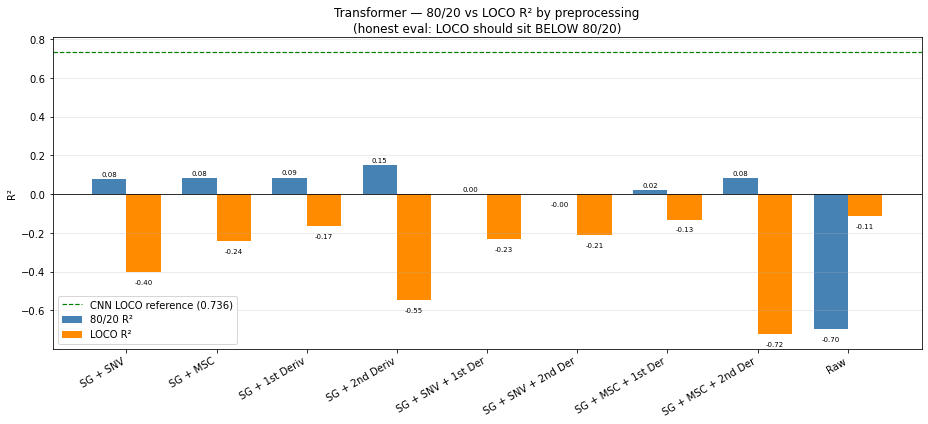


=== Sanity check (LOCO should be <= 80/20) ===
SG + SNV               80/20 +0.076   LOCO -0.401
SG + MSC               80/20 +0.084   LOCO -0.244
SG + 1st Deriv         80/20 +0.085   LOCO -0.165
SG + 2nd Deriv         80/20 +0.148   LOCO -0.546
SG + SNV + 1st Der     80/20 +0.001   LOCO -0.232
SG + SNV + 2nd Der     80/20 -0.001   LOCO -0.212
SG + MSC + 1st Der     80/20 +0.022   LOCO -0.131
SG + MSC + 2nd Der     80/20 +0.084   LOCO -0.724
Raw                    80/20 -0.697   LOCO -0.112  ⚠ LOCO > 80/20 — check for leakage


In [13]:
import matplotlib.pyplot as plt
import numpy as np

df = df_transformer.copy()
labels = df["Preprocessing"].tolist()
x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(figsize=(13, 6))

b1 = ax.bar(x - w/2, df["R2_8020"], w, label="80/20 R²", color="steelblue")
b2 = ax.bar(x + w/2, df["R2_LOCO"], w, label="LOCO R²", color="darkorange")

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.736, color="green", linewidth=1.2, linestyle="--",
           label="CNN LOCO reference (0.736)")

ax.set_ylabel("R²")
ax.set_title("Transformer — 80/20 vs LOCO R² by preprocessing\n(honest eval: LOCO should sit BELOW 80/20)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# annotate each bar with its value
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3 if h >= 0 else -12),
                    textcoords="offset points",
                    ha="center", fontsize=7)

plt.tight_layout()
plt.savefig("transformer_8020_vs_loco.png", dpi=150, bbox_inches="tight")
plt.show()

# honesty check: flag any row where LOCO beats 80/20 (the leakage signature)
print("\n=== Sanity check (LOCO should be <= 80/20) ===")
for _, r in df.iterrows():
    flag = "  ⚠ LOCO > 80/20 — check for leakage" if r["R2_LOCO"] > r["R2_8020"] else ""
    print(f"{r['Preprocessing']:<22} 80/20 {r['R2_8020']:+.3f}   LOCO {r['R2_LOCO']:+.3f}{flag}")

    

Final run for: SG + MSC
Epoch  10/100 — Train Loss: 0.03900  Val Loss: 0.02079
Epoch  20/100 — Train Loss: 0.03266  Val Loss: 0.02258
Epoch  30/100 — Train Loss: 0.02693  Val Loss: 0.02875
Epoch  40/100 — Train Loss: 0.02145  Val Loss: 0.00816
Epoch  50/100 — Train Loss: 0.01689  Val Loss: 0.00717
Epoch  60/100 — Train Loss: 0.01416  Val Loss: 0.00820
Epoch  70/100 — Train Loss: 0.01184  Val Loss: 0.00636
Epoch  80/100 — Train Loss: 0.01073  Val Loss: 0.00658
Epoch  90/100 — Train Loss: 0.01026  Val Loss: 0.00616
Epoch 100/100 — Train Loss: 0.01036  Val Loss: 0.00646

Best validation loss: 0.00553
Epoch  10/100 — Train Loss: 0.03695  Val Loss: 0.08831
Epoch  20/100 — Train Loss: 0.03017  Val Loss: 0.02137
Epoch  30/100 — Train Loss: 0.02258  Val Loss: 0.03840
Epoch  40/100 — Train Loss: 0.01552  Val Loss: 0.03130
Epoch  50/100 — Train Loss: 0.01039  Val Loss: 0.02291
Epoch  60/100 — Train Loss: 0.00740  Val Loss: 0.02374
Epoch  70/100 — Train Loss: 0.00614  Val Loss: 0.02491
Epoch  80/

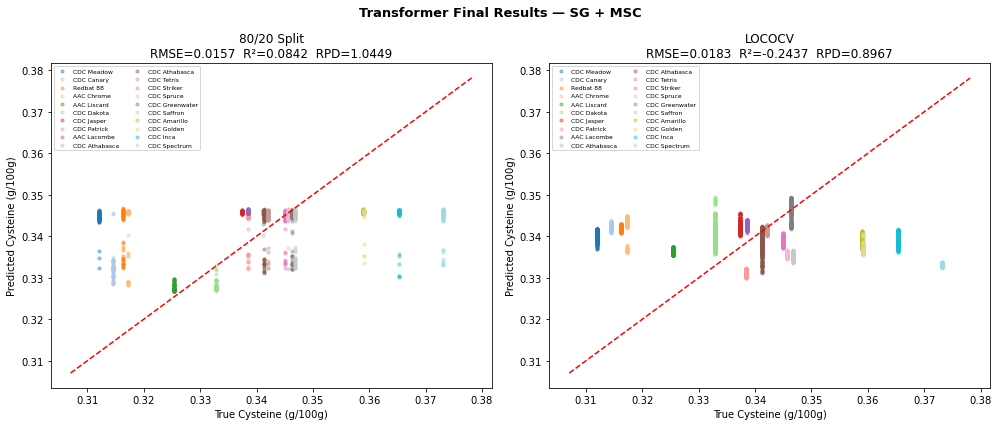


    TRANSFORMER FINAL RESULTS SUMMARY
Metric                   80/20 Split          LOCOCV
-------------------------------------------------------
RMSE                          0.0157          0.0183
R²                            0.0842         -0.2437
RPD                           1.0449          0.8967
Preprocessing               SG + MSC        SG + MSC


In [15]:
CHOSEN_PREP = "SG + MSC"      

print(f"Final run for: {CHOSEN_PREP}")

if CHOSEN_PREP == "Raw":
    X_best = X.copy()
    prep_fn = None
else:
    prep_fn = preprocessing_combos[CHOSEN_PREP]
    X_best  = prep_fn(X)

# ── 80/20 with separate validation slice (test never used for checkpointing) ──
X_tr, X_te, y_tr, y_te = train_test_split(X_best, y, test_size=0.2, random_state=42)
X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=0.2, random_state=42)

torch.manual_seed(42)
model_final = SpectralTransformer(
    input_size=1530, patch_size=51,
    d_model=128, nhead=8, num_layers=3, dropout=0.3
)
model_final, _, _ = train_model(
    model=model_final,
    X_train=X_tr2, y_train=y_tr2,
    X_val=X_val,   y_val=y_val,
    epochs=100, batch_size=32, lr=1e-4
)

model_final.eval()
with torch.no_grad():
    y_pred_te = model_final(torch.FloatTensor(X_te).to(device)).cpu().numpy().flatten()

# ── LOCOCV, leakage-free: validate on a TRAINING cultivar, batch preprocessing ──
all_true_final, all_pred_final = [], []
for fold_idx, held_out in enumerate(cultivar_names):
    train_cults = [c for c in cultivar_names if c != held_out]
    val_cult    = train_cults[-1]

    X_tr_l, y_tr_l   = [], []
    X_val_l, y_val_l = [], []
    X_te_l, y_te_l   = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        if not spectra:
            continue
        intens_batch = np.array([s[1] for s in spectra])     # (324, 1530)
        pre = intens_batch if prep_fn is None else prep_fn(intens_batch)

        if folder_name == held_out:
            X_te_l.extend(pre);  y_te_l.extend([meta['cys']] * len(pre))
        elif folder_name == val_cult:
            X_val_l.extend(pre); y_val_l.extend([meta['cys']] * len(pre))
        else:
            X_tr_l.extend(pre);  y_tr_l.extend([meta['cys']] * len(pre))

    torch.manual_seed(42)
    model_loco_f = SpectralTransformer(
        input_size=1530, patch_size=51,
        d_model=128, nhead=8, num_layers=3, dropout=0.3
    )
    model_loco_f, _, _ = train_model(
        model=model_loco_f,
        X_train=np.array(X_tr_l),  y_train=np.array(y_tr_l),
        X_val=np.array(X_val_l),   y_val=np.array(y_val_l),
        epochs=100, batch_size=32, lr=1e-4
    )

    model_loco_f.eval()
    with torch.no_grad():
        y_pred_l = model_loco_f(
            torch.FloatTensor(np.array(X_te_l)).to(device)
        ).cpu().numpy().flatten()

    all_true_final.extend(y_te_l)
    all_pred_final.extend(y_pred_l)
    fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
    print(f"Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")

all_true_final = np.array(all_true_final)
all_pred_final = np.array(all_pred_final)

# ── metrics ──
rmse_8020_f = np.sqrt(mean_squared_error(y_te, y_pred_te))
r2_8020_f   = r2_score(y_te, y_pred_te)
rpd_8020_f  = y_te.std() / rmse_8020_f
rmse_loco_f = np.sqrt(mean_squared_error(all_true_final, all_pred_final))
r2_loco_f   = r2_score(all_true_final, all_pred_final)
rpd_loco_f  = all_true_final.std() / rmse_loco_f

# ── Scatter, coloured by cultivar ──
colors = plt.cm.tab20(np.linspace(0, 1, 20))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
unique_cys = sorted(set(y_te))
for i, val in enumerate(unique_cys):
    mask  = y_te == val
    label = [meta['label'] for meta in CULTIVARS.values() if abs(meta['cys'] - val) < 0.0001]
    label = label[0] if label else str(round(val, 4))
    ax1.scatter(y_te[mask], y_pred_te[mask], alpha=0.4, s=10,
                color=colors[i % 20], label=label)
min_val = min(y_te.min(), y_pred_te.min()) - 0.005
max_val = max(y_te.max(), y_pred_te.max()) + 0.005
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
ax1.set_xlabel("True Cysteine (g/100g)")
ax1.set_ylabel("Predicted Cysteine (g/100g)")
ax1.set_title(f"80/20 Split\nRMSE={rmse_8020_f:.4f}  R²={r2_8020_f:.4f}  RPD={rpd_8020_f:.4f}")
ax1.legend(fontsize=6, ncol=2, loc='upper left')

ax2 = axes[1]
unique_cys_loco = sorted(set(all_true_final))
for i, val in enumerate(unique_cys_loco):
    mask  = all_true_final == val
    label = [meta['label'] for meta in CULTIVARS.values() if abs(meta['cys'] - val) < 0.0001]
    label = label[0] if label else str(round(val, 4))
    ax2.scatter(all_true_final[mask], all_pred_final[mask], alpha=0.4, s=10,
                color=colors[i % 20], label=label)
min_val = min(all_true_final.min(), all_pred_final.min()) - 0.005
max_val = max(all_true_final.max(), all_pred_final.max()) + 0.005
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
ax2.set_xlabel("True Cysteine (g/100g)")
ax2.set_ylabel("Predicted Cysteine (g/100g)")
ax2.set_title(f"LOCOCV\nRMSE={rmse_loco_f:.4f}  R²={r2_loco_f:.4f}  RPD={rpd_loco_f:.4f}")
ax2.legend(fontsize=6, ncol=2, loc='upper left')

plt.suptitle(f"Transformer Final Results — {CHOSEN_PREP}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Transformer_final_{CHOSEN_PREP.replace(' ', '_').replace('+','')}.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("    TRANSFORMER FINAL RESULTS SUMMARY")
print("="*55)
print(f"{'Metric':<20} {'80/20 Split':>15} {'LOCOCV':>15}")
print("-"*55)
print(f"{'RMSE':<20} {rmse_8020_f:>15.4f} {rmse_loco_f:>15.4f}")
print(f"{'R²':<20} {r2_8020_f:>15.4f} {r2_loco_f:>15.4f}")
print(f"{'RPD':<20} {rpd_8020_f:>15.4f} {rpd_loco_f:>15.4f}")
print(f"{'Preprocessing':<20} {CHOSEN_PREP:>15} {CHOSEN_PREP:>15}")
print("="*55)